# Drought Data Analysis and Processing

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 


In [2]:
fresno_drought = pd.read_csv("../../data/FresnoDrought_export_20050101_20181231.csv")

In [3]:
fresno_drought.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
0,20181225,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-25,2018-12-31,1
1,20181218,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-18,2018-12-24,1
2,20181211,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-11,2018-12-17,1
3,20181204,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-04,2018-12-10,1
4,20181127,6019,Fresno County,CA,0.00,100.00,47.19,0.0,0.0,0.0,2018-11-27,2018-12-03,1


In [4]:
df = fresno_drought.copy()

In [5]:
df["DSCI"] = 1*df["D0"] + 2*df["D1"] + 3*df["D2"] + 4 * df["D3"] + 5 * df["D4"]

In [6]:
df.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID,DSCI
0,20181225,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-25,2018-12-31,1,169.59
1,20181218,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-18,2018-12-24,1,169.59
2,20181211,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-11,2018-12-17,1,169.59
3,20181204,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-04,2018-12-10,1,169.59
4,20181127,6019,Fresno County,CA,0.00,100.00,47.19,0.0,0.0,0.0,2018-11-27,2018-12-03,1,194.38


In [7]:
df['MapDate'] = pd.to_datetime(df["MapDate"], format='%Y%m%d')

In [8]:
df

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID,DSCI
0,2018-12-25,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-25,2018-12-31,1,169.59
1,2018-12-18,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-18,2018-12-24,1,169.59
2,2018-12-11,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-11,2018-12-17,1,169.59
3,2018-12-04,6019,Fresno County,CA,24.79,75.21,47.19,0.0,0.0,0.0,2018-12-04,2018-12-10,1,169.59
4,2018-11-27,6019,Fresno County,CA,0.00,100.00,47.19,0.0,0.0,0.0,2018-11-27,2018-12-03,1,194.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2005-01-25,6019,Fresno County,CA,100.00,0.00,0.00,0.0,0.0,0.0,2005-01-25,2005-01-31,1,0.00
727,2005-01-18,6019,Fresno County,CA,100.00,0.00,0.00,0.0,0.0,0.0,2005-01-18,2005-01-24,1,0.00
728,2005-01-11,6019,Fresno County,CA,100.00,0.00,0.00,0.0,0.0,0.0,2005-01-11,2005-01-17,1,0.00
729,2005-01-04,6019,Fresno County,CA,94.82,5.18,0.00,0.0,0.0,0.0,2005-01-04,2005-01-10,1,5.18


In [9]:
# 2. Group by Month and Year, then average the DSCI
# Using 'MS' (Month Start) is best for keeping the dates consistent
monthly_dsci = df.resample('MS', on='MapDate')['DSCI'].mean().reset_index()

# 3. Rename columns for clarity in your LSTM
monthly_dsci.columns = ['Date', 'Avg_Monthly_DSCI']

print(monthly_dsci.head())

        Date  Avg_Monthly_DSCI
0 2004-12-01            85.370
1 2005-01-01             1.295
2 2005-02-01             0.000
3 2005-03-01             0.000
4 2005-04-01             0.000


In [10]:
monthly_dsci

,Date,Avg_Monthly_DSCI
0,2004-12-01,85.370
1,2005-01-01,1.295
2,2005-02-01,0.000
3,2005-03-01,0.000
4,2005-04-01,0.000
...,...,...
164,2018-08-01,179.615
165,2018-09-01,179.610
166,2018-10-01,162.874
167,2018-11-01,190.760


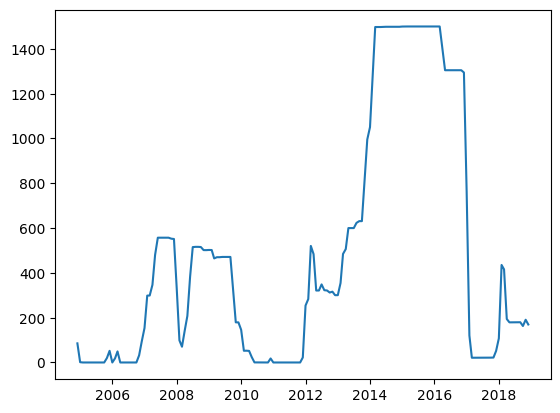

In [11]:
x = monthly_dsci['Date']
y = monthly_dsci['Avg_Monthly_DSCI']
plt.figure()
plt.plot(x,y)



In [12]:
filtered_df = monthly_dsci[(monthly_dsci['Date'] >= '2008-10-01') & (monthly_dsci['Date'] <='2015-12-01')]

In [13]:
filtered_df.loc[:, 'Date'] = filtered_df['Date'].dt.to_period('M')

/var/folders/ln/jmk8y3l53bn8df07060rw51r0000gn/T/ipykernel_63262/1920963425.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<PeriodArray>
['2008-10', '2008-11', '2008-12', '2009-01', '2009-02', '2009-03', '2009-04',
 '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10', '2009-11',
 '2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06',
 '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01',
 '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08',
 '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03',
 '2012-04', '2012-05', '2012-06', '2012-07', '2012-08', '2012-09', '2012-10',
 '2012-11', '2012-12', '2013-01', '2013-02', '2013-03', '2013-04', '2013-05',
 '2013-06', '2013-07', '2013-08', '2013-09', '2013-10', '2013-11', '2013-12',
 '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07',
 '2014

In [14]:
filtered_df.set_index('Date')

,Avg_Monthly_DSCI
Date,
2008-10,515.4225
2008-11,501.6900
2008-12,501.5300
2009-01,502.2950
2009-02,501.9950
...,...
2015-08,1500.0000
2015-09,1500.0000
2015-10,1500.0000


In [15]:
data_df = pd.read_csv("../../data/merged_rodent_fresno_agg.csv")

In [16]:
data_df

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED
0,2008-10,6.156349,163.91,0.18,0.0,3.667742,87.825806,70.0,53.0,0,23.056051,782.3835
1,2008-11,3.407979,17.30,1.49,0.0,3.106667,74.490000,95.5,38.5,0,0.519323,515.6780
2,2008-12,6.486154,0.00,1.19,0.0,3.306452,79.312903,94.0,18.5,0,0.000000,238.7675
3,2009-01,6.619800,1.00,1.25,0.0,2.587097,62.019355,102.0,33.0,0,24.630400,395.1969
4,2009-02,5.751629,28.00,2.33,0.0,3.928571,94.096429,51.5,13.0,0,71.542885,375.1287
...,...,...,...,...,...,...,...,...,...,...,...,...
82,2015-08,2.569621,28.06,0.00,0.0,4.900000,117.664516,63.0,44.0,0,737.718551,1423.6719
83,2015-09,2.775191,210.76,0.06,0.0,4.046667,97.216667,62.0,52.0,0,544.970947,2064.4267
84,2015-10,5.344812,16.99,0.41,0.0,3.503226,84.058065,63.0,38.0,0,181.244457,1673.8602
85,2015-11,2.569621,30.46,2.13,0.0,3.116667,74.736667,75.0,26.5,0,263.108466,1307.2290


In [17]:
filtered_df = filtered_df.rename(columns = {'Date': 'YEAR_MONTH'})
filtered_df.reset_index()

,index,YEAR_MONTH,Avg_Monthly_DSCI
0,46,2008-10,515.4225
1,47,2008-11,501.6900
2,48,2008-12,501.5300
3,49,2009-01,502.2950
4,50,2009-02,501.9950
...,...,...,...
82,128,2015-08,1500.0000
83,129,2015-09,1500.0000
84,130,2015-10,1500.0000
85,131,2015-11,1500.0000


In [18]:
# Convert both to string format 'YYYY-MM'
data_df['YEAR_MONTH'] = data_df['YEAR_MONTH'].astype(str)
filtered_df['YEAR_MONTH'] = filtered_df['YEAR_MONTH'].astype(str)

# Now the merge will work
df_total = pd.merge(data_df, filtered_df, on='YEAR_MONTH')


In [19]:

df_total

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED,Avg_Monthly_DSCI
0,2008-10,6.156349,163.91,0.18,0.0,3.667742,87.825806,70.0,53.0,0,23.056051,782.3835,515.4225
1,2008-11,3.407979,17.30,1.49,0.0,3.106667,74.490000,95.5,38.5,0,0.519323,515.6780,501.6900
2,2008-12,6.486154,0.00,1.19,0.0,3.306452,79.312903,94.0,18.5,0,0.000000,238.7675,501.5300
3,2009-01,6.619800,1.00,1.25,0.0,2.587097,62.019355,102.0,33.0,0,24.630400,395.1969,502.2950
4,2009-02,5.751629,28.00,2.33,0.0,3.928571,94.096429,51.5,13.0,0,71.542885,375.1287,501.9950
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,2015-08,2.569621,28.06,0.00,0.0,4.900000,117.664516,63.0,44.0,0,737.718551,1423.6719,1500.0000
83,2015-09,2.775191,210.76,0.06,0.0,4.046667,97.216667,62.0,52.0,0,544.970947,2064.4267,1500.0000
84,2015-10,5.344812,16.99,0.41,0.0,3.503226,84.058065,63.0,38.0,0,181.244457,1673.8602,1500.0000
85,2015-11,2.569621,30.46,2.13,0.0,3.116667,74.736667,75.0,26.5,0,263.108466,1307.2290,1500.0000


In [20]:
df_total.to_csv('../../data/fresno_agg_drought.csv', index=False)